# Week 2 – Exploratory Data Analysis for Retail Demand Forecasting

## Project
Demand Forecasting for Retail Inventory Optimization

## Objective

The objective of this stage is to perform exploratory data analysis (EDA) on the retail dataset to:

1. Understand the **target variable behavior**
2. Analyze **feature relationships**
3. Identify **potential new features**
4. Evaluate **feature importance**
5. Apply **normalization and standardization**
6. Investigate **multicollinearity**
7. Generate **derived features using PCA**

This analysis helps determine whether the dataset contains sufficient information to build an effective demand forecasting model.

---

## Target Variable

The target variable for this analysis is:

`Daily_Units_Sold`

This represents the number of product units sold per day for a specific product in a given store.

---

## Dataset Overview

The dataset includes multiple feature categories:

### Time Features
- Date
- DayOfWeek
- Month
- Year
- Is_Weekend
- Is_Holiday

### Product Features
- Product_ID
- Category

### Pricing Features
- Base_Price
- Discount_Percentage
- Current_Price
- Competitor_Price

### Store Features
- Store_ID
- Store_Type

### External Factors
- Avg_Temperature
- Rainfall_mm
- Social_Media_Sentiment
- Footfall_Index

### Inventory Features
- Lead_Time_Days
- Safety_Stock_Level
- Stock_On_Hand

These variables help capture the various factors influencing retail demand.

---

## Python Libraries Used

The following libraries are used for analysis:

| Library | Purpose |
|------|------|
| pandas | Data manipulation |
| numpy | Numerical computations |
| matplotlib | Visualization |
| seaborn | Statistical visualization |
| scikit-learn | Machine learning utilities |
| statsmodels | Statistical analysis |
| shap | Feature importance explainability |

In [1]:
# @title Import required libraries

# pandas is used for loading and manipulating tabular data.
import pandas as pd

# numpy is used for numerical operations.
import numpy as np

# matplotlib and seaborn are used for charts and visual analysis.
import matplotlib.pyplot as plt
import seaborn as sns

# StandardScaler is used to standardize numerical features before PCA.
# MinMaxScaler is imported for normalization if needed later.
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# PCA is used to create new features that capture maximum variance.
from sklearn.decomposition import PCA

# RandomForestRegressor is used to estimate feature importance.
from sklearn.ensemble import RandomForestRegressor

# permutation_importance measures how much each feature matters by shuffling it.
from sklearn.inspection import permutation_importance

# train_test_split divides the data into training and testing sets.
from sklearn.model_selection import train_test_split

# statsmodels is used for statistical analysis such as VIF.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Set a clean plot style for all charts.
sns.set(style="whitegrid")

# 1. Load Dataset

The first step is to load the dataset and inspect its structure.

Key tasks:
- Check dataset shape
- Inspect data types
- Preview records

In [2]:
# @title Load dataset

# Read the CSV file into a pandas DataFrame.
df = pd.read_csv("/content/dataset1.csv")

# Print the number of rows and columns in the dataset.
print("Dataset Shape:", df.shape)

# Display the first few rows to understand the structure of the data.
df.head()

Dataset Shape: (2000, 22)


,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,...,Store_Type,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold
0,4/13/2023,3,4,2023,0,0,1002,Grocery,410.09,0.01,...,Urban,411.58,127.6,29.1,8.5,0.63,7,141,471,83
1,12/15/2023,4,12,2023,0,0,1014,Home,89.98,0.30,...,Rural,90.37,56.9,1.9,5.3,0.35,11,59,263,102
2,9/28/2023,3,9,2023,0,0,1015,Electronics,404.88,0.14,...,Urban,408.07,191.8,14.5,2.8,0.77,4,111,302,89
3,4/17/2023,0,4,2023,0,0,1012,Grocery,347.97,0.43,...,Urban,349.20,71.6,24.4,1.3,0.86,11,38,389,98
4,3/13/2023,0,3,2023,0,0,1016,Grocery,280.16,0.14,...,Urban,252.64,185.5,26.0,0.4,0.36,14,46,262,100


# 2. Basic Dataset Inspection

This step verifies:

- Data types
- Missing values
- Duplicate records

In [3]:
# Display data types, non-null counts, and memory usage.
# This helps us understand the structure of the dataset.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    2000 non-null   object 
 1   DayOfWeek               2000 non-null   int64  
 2   Month                   2000 non-null   int64  
 3   Year                    2000 non-null   int64  
 4   Is_Weekend              2000 non-null   int64  
 5   Is_Holiday              2000 non-null   int64  
 6   Product_ID              2000 non-null   int64  
 7   Category                2000 non-null   object 
 8   Base_Price              2000 non-null   float64
 9   Discount_Percentage     2000 non-null   float64
 10  Current_Price           2000 non-null   float64
 11  Store_ID                2000 non-null   int64  
 12  Store_Type              2000 non-null   object 
 13  Competitor_Price        2000 non-null   float64
 14  Footfall_Index          2000 non-null   

In [4]:
# @title Check missing values

# Count missing values in each column.
# A value of 0 means that the column has no missing entries.
df.isnull().sum()

,0
Date,0
DayOfWeek,0
Month,0
Year,0
Is_Weekend,0
Is_Holiday,0
Product_ID,0
Category,0
Base_Price,0
Discount_Percentage,0


In [5]:
# @title Check duplicate rows

# Count the number of completely duplicated rows.
# If the result is 0, there are no exact duplicate records.
df.duplicated().sum()

np.int64(0)

# Observations

- The dataset contains **2000 rows and 22 columns**, which is a good size for exploratory analysis in an academic project.
- The `info()` output shows that the dataset contains a mix of **numerical and categorical/date-related fields**.
- There are **no missing values** in any column, so no imputation is needed at this stage.
- There are **0 duplicate rows**, which means the records are unique and the dataset is clean enough to proceed with EDA.

# 3. Target Variable Analysis

Understanding the distribution of the target variable is critical before building forecasting models.

We analyze:

- Distribution of Daily Units Sold
- Summary statistics
- Outliers

In [6]:
# Generate descriptive statistics for the target variable.
# This shows the count, mean, standard deviation, minimum,
# quartiles, and maximum for Daily_Units_Sold.
df["Daily_Units_Sold"].describe()

,Daily_Units_Sold
count,2000.000000
mean,112.263000
std,28.575726
min,17.000000
25%,93.000000
50%,113.000000
75%,133.000000
max,204.000000


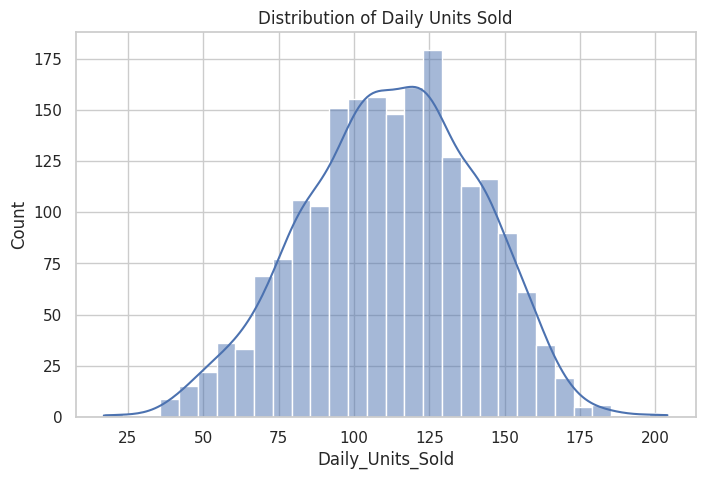

In [7]:
# Create a histogram with a density curve for the target variable.
# The histogram shows how the sales values are distributed.
# The KDE line helps us see the overall shape more smoothly.
plt.figure(figsize=(8,5))
sns.histplot(df["Daily_Units_Sold"], kde=True)
plt.title("Distribution of Daily Units Sold")
plt.xlabel("Daily Units Sold")
plt.ylabel("Frequency")
plt.show()

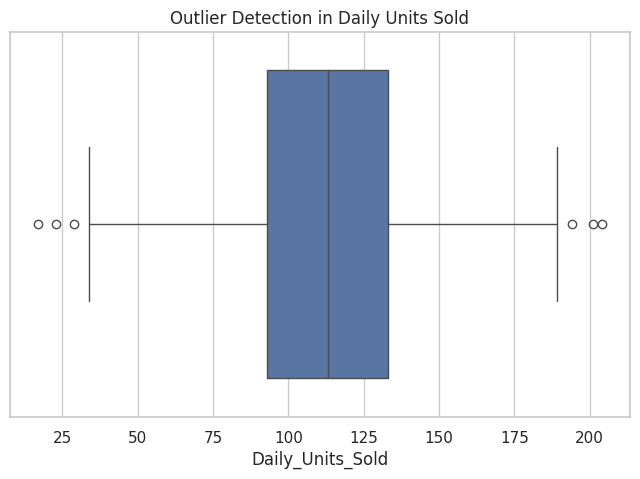

In [8]:
# Create a boxplot for the target variable.
# A boxplot is useful for spotting possible outliers.
plt.figure(figsize=(8,5))
sns.boxplot(x=df["Daily_Units_Sold"])
plt.title("Outlier Detection in Daily Units Sold")
plt.xlabel("Daily Units Sold")
plt.show()

# Observation: Outlier Detection

The target variable **`Daily_Units_Sold`** appears suitable for further analysis.

From the summary statistics:

- Mean = **112.26 units**
- Median = **113 units**
- Standard deviation = **28.58 units**
- Minimum = **17 units**
- Maximum = **204 units**

The mean and median are almost identical, which suggests that the distribution is reasonably balanced around the center. The histogram shows that most observations are concentrated around the middle range, while the boxplot indicates only a **small number of extreme values**.

In a retail dataset, such unusually high or low sales values may occur because of discounts, holidays, weather conditions, or changes in customer traffic. Therefore, these points are more likely to represent **genuine demand variation** than data-entry errors.

At this stage, **no outlier removal is necessary**, and the target variable can be used directly for modeling.


# 4. Correlation Analysis

Correlation analysis helps identify which features are strongly associated with the target variable.

This provides initial insights into which variables may influence demand.

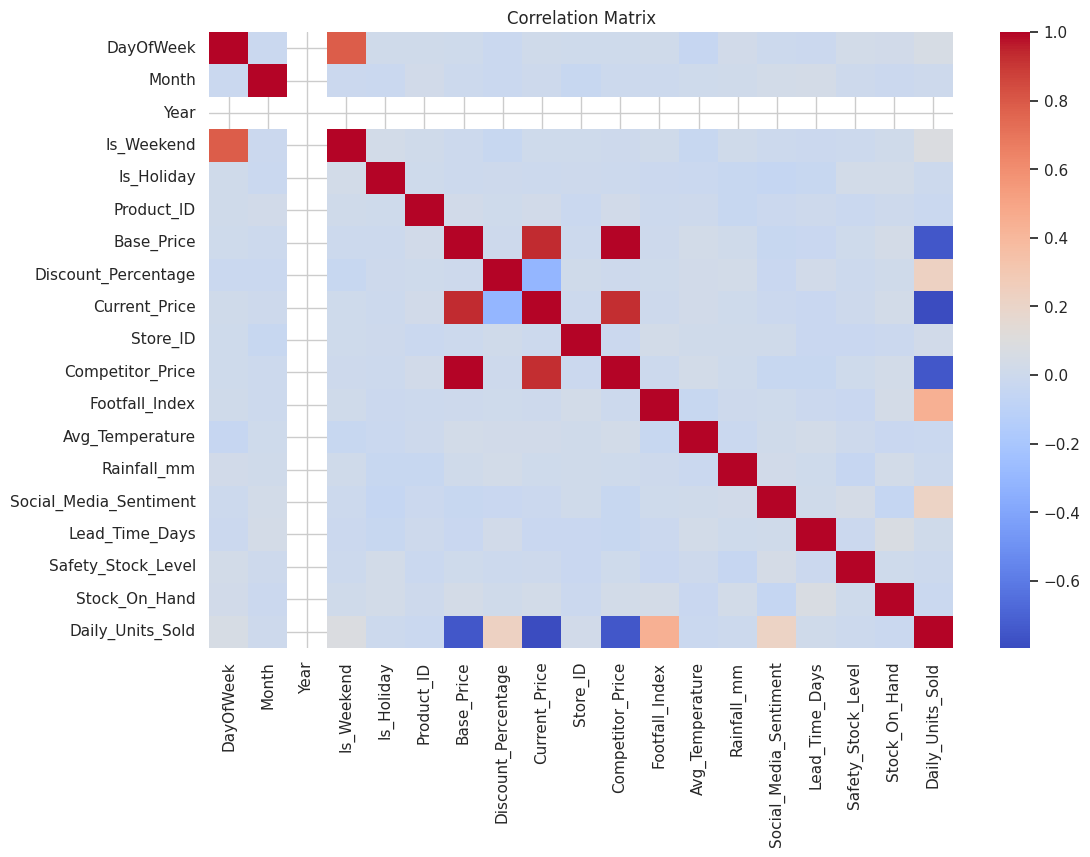

In [9]:
# Select only numerical columns for correlation analysis.
numeric_df = df.select_dtypes(include=[np.number])

# Compute the correlation matrix for all numerical variables.
corr = numeric_df.corr()

# Plot the correlation matrix as a heatmap.
# Strong positive correlations appear toward one end of the color scale,
# while strong negative correlations appear toward the other.
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

# Observation: Correlation Analysis

The correlation analysis provides an initial view of how the numeric features move with **`Daily_Units_Sold`**.

The main observations are:

1. **`Current_Price` has a strong negative relationship with sales.** This suggests that when the selling price increases, the number of units sold tends to decrease.

2. **`Footfall_Index` has the strongest positive relationship with sales among the predictors.** This indicates that higher customer traffic is associated with higher product demand.

3. **`Discount_Percentage` and `Social_Media_Sentiment` show positive relationships with sales.** These variables may capture the effects of promotions and customer perception.

4. **`Base_Price`, `Current_Price`, and `Competitor_Price` are strongly correlated with one another.** This is expected because all three variables describe related aspects of pricing.

Overall, the heatmap suggests that **price-related variables and customer activity indicators are likely to be the most useful predictors** in the demand forecasting model.


# 5. Feature Scaling

Machine learning models and PCA require properly scaled features.

Two scaling approaches are used:

### 1. Standardization
Transforms data to zero mean and unit variance.

### 2. Normalization
Scales data between 0 and 1.

In [10]:
# Create a standard scaler object.
scaler = StandardScaler()

# Standardize all numerical features so that they have mean 0 and standard deviation 1.
scaled_features = scaler.fit_transform(numeric_df)

# Convert the scaled output back into a DataFrame for easier viewing.
scaled_df = pd.DataFrame(scaled_features, columns=numeric_df.columns)

# Display the first few rows of the standardized data.
scaled_df.head()

,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Base_Price,Discount_Percentage,Current_Price,Store_ID,Competitor_Price,Footfall_Index,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold
0,-0.014786,-0.732328,0.0,-0.630574,-0.320212,-1.378860,1.151043,-1.683292,1.928120,0.742427,1.151539,0.023566,1.192724,0.632445,0.405150,-0.197725,0.652851,1.491768,-1.024307
1,0.486429,1.575581,0.0,-0.630574,-0.320212,0.719196,-1.106765,0.367606,-1.073936,-0.633234,-1.095417,-1.640816,-1.161649,0.015501,-0.567724,0.817551,-0.844493,0.070877,-0.359241
2,-0.014786,0.710115,0.0,-0.630574,-0.320212,0.894034,1.114296,-0.763924,1.422322,1.086343,1.126986,1.534929,-0.071021,-0.466487,0.891587,-0.959182,0.105042,0.337294,-0.814286
3,-1.518431,-0.732328,0.0,-0.630574,-0.320212,0.369520,0.712897,1.286974,0.110695,0.226554,0.715173,-1.294757,0.785902,-0.755680,1.204296,0.817551,-1.227959,0.931609,-0.499255
4,-1.518431,-1.020817,0.0,-0.630574,-0.320212,1.068872,0.234617,-0.763924,0.483545,1.258300,0.039708,1.386618,0.924394,-0.929196,-0.532979,1.579007,-1.081876,0.064046,-0.429248


# Observations from Feature Scaling

- Standardization converts numerical features to a common scale with **mean 0** and **standard deviation 1**.
- This step is especially important before applying **PCA**, because PCA is sensitive to differences in feature scale.
- After scaling, large-value features such as prices and stock levels no longer dominate the analysis simply because of their units.
- At this stage, scaling is used for **analysis and feature engineering**, not for dropping or changing the meaning of any original feature.

# 6. Multicollinearity Analysis (VIF)

Variance Inflation Factor (VIF) is used to detect multicollinearity between features.

High VIF indicates that a variable can be predicted from other variables.

In [11]:
# Remove the target variable from the feature matrix.
X = numeric_df.drop(columns=["Daily_Units_Sold"])

# Add a constant term because statsmodels VIF calculation expects it.
X = sm.add_constant(X)

# Create an empty DataFrame to store VIF values.
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns

# Calculate VIF for each feature.
# Higher VIF means stronger multicollinearity with other variables.
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

# Show the VIF table.
vif_data

,Feature,VIF
0,DayOfWeek,2.626707
1,Month,1.005365
2,Year,31348.978095
3,Is_Weekend,2.624148
4,Is_Holiday,1.008419
5,Product_ID,1.004165
6,Base_Price,109.061670
7,Discount_Percentage,4.153158
8,Current_Price,33.589540
9,Store_ID,1.005594


# Observation: Multicollinearity Analysis (VIF)

Variance Inflation Factor (VIF) was used to check whether some predictors contain overlapping information.

The main results are:

- **`Year` has an extremely high VIF (≈ 31,348.98)** because the dataset contains only one year, so this column behaves almost like a constant.
- **`Base_Price` has a very high VIF (≈ 109.06)**.
- **`Competitor_Price` also has a very high VIF (≈ 75.72)**.
- **`Current_Price` has a high VIF as well (≈ 33.59)**.

These large values indicate strong multicollinearity among the pricing variables. This is not surprising because **`Current_Price` is derived from `Base_Price` and `Discount_Percentage`**, while competitor price often changes in the same general direction as market price.

Since the project requirement states that **no existing features should be dropped**, these variables will be retained. However, their multicollinearity should be acknowledged when interpreting model behavior.


# 7. Feature Importance Using Random Forest

Random Forest models are useful for estimating feature importance because they capture nonlinear relationships.

This helps identify which features have the strongest predictive influence on demand.

In [12]:
# Separate input features (X) and the target variable (y).
X = numeric_df.drop(columns=["Daily_Units_Sold"])
y = numeric_df["Daily_Units_Sold"]

# Split the dataset into training and testing sets.
# 80% is used for training and 20% for testing.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the Random Forest model.
# random_state is set so the results are reproducible.
model = RandomForestRegressor(random_state=42)

# Train the model on the training data.
model.fit(X_train, y_train)

# Extract feature importance values from the trained model.
importances = model.feature_importances_

# Create a sorted DataFrame so the most important features appear first.
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Display feature importance scores.
importance_df

,Feature,Importance
8,Current_Price,0.626362
11,Footfall_Index,0.205387
14,Social_Media_Sentiment,0.048041
10,Competitor_Price,0.023097
6,Base_Price,0.018075
12,Avg_Temperature,0.010211
13,Rainfall_mm,0.009424
16,Safety_Stock_Level,0.008921
17,Stock_On_Hand,0.008753
9,Store_ID,0.007295


# Observation: Feature Importance Using Random Forest

The Random Forest model estimates feature importance based on how much each variable helps reduce prediction error.

The most important features are:

1. **`Current_Price` (importance ≈ 0.626)**  
   This is by far the strongest predictor, showing that price has the greatest influence on sales in this dataset.

2. **`Footfall_Index` (importance ≈ 0.205)**  
   This confirms that customer traffic is the second most important driver of demand.

3. **`Social_Media_Sentiment` (importance ≈ 0.048)**  
   This suggests that customer opinion or product perception has a measurable effect on sales.

Other variables such as **`Competitor_Price`**, **`Base_Price`**, **`Avg_Temperature`**, and **`Rainfall_mm`** contribute smaller but still noticeable amounts.

Overall, the Random Forest results indicate that **pricing and customer activity are the dominant influences on daily retail demand** in this dataset.


# 8. Permutation Feature Importance

Permutation importance evaluates feature relevance by measuring how model performance changes when a feature is randomly shuffled.

In [13]:
# Compute permutation importance on the test set.
# The model performance is measured again after shuffling each feature.
# If the score drops a lot, that feature is important.
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

# Store the average importance for each feature in a DataFrame.
perm_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

# Display the permutation importance table.
perm_df

,Feature,Importance
8,Current_Price,1.064552
11,Footfall_Index,0.387192
14,Social_Media_Sentiment,0.059614
10,Competitor_Price,0.001381
0,DayOfWeek,0.001165
17,Stock_On_Hand,0.000885
6,Base_Price,0.000862
12,Avg_Temperature,0.000789
3,Is_Weekend,0.000779
15,Lead_Time_Days,0.000638


# Observation: Permutation Feature Importance

Permutation importance checks how much model performance worsens when each feature is randomly shuffled.

This method confirms the Random Forest findings:

1. **`Current_Price` remains the most important feature (importance ≈ 1.065).**  
   This strongly reinforces the conclusion that selling price is the main predictor of daily demand.

2. **`Footfall_Index` remains the second most important feature (importance ≈ 0.387).**  
   This again shows that customer traffic has a major effect on sales.

3. **`Social_Media_Sentiment` continues to have meaningful importance (importance ≈ 0.060).**  
   Although much smaller than the top two, it still adds predictive value.

Most other variables have very small importance values, and a few are slightly negative. This usually means that those variables contribute little on their own or that their signal overlaps with other predictors.

Because both methods highlight the same top variables, we can be more confident that **price and customer activity are the key drivers of demand in this dataset**.


# 9. Principal Component Analysis (PCA)

Principal Component Analysis is used to derive new features that capture the highest variance in the dataset.

In this project we do **not remove existing features**, but PCA components may provide additional predictive signals.

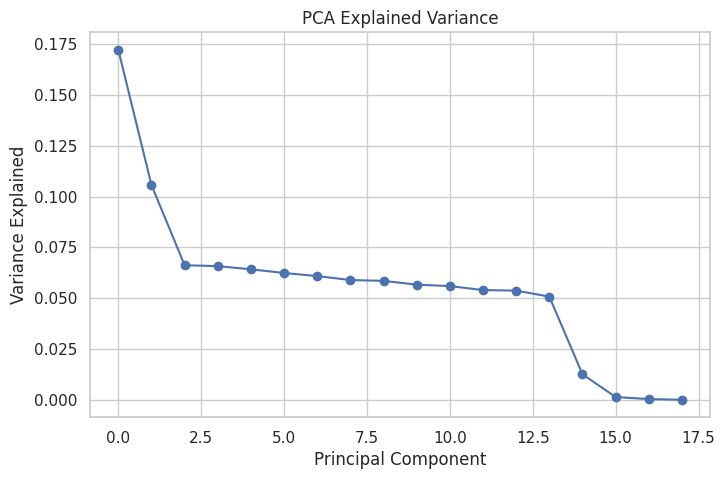

In [14]:
# Create a PCA object without limiting the number of components.
# This allows us to inspect how much variance each component explains.
pca = PCA()

# Fit PCA on the standardized feature set.
# The target variable is excluded because PCA should be based only on inputs.
pca.fit(scaled_df.drop(columns=["Daily_Units_Sold"]))

# Store the proportion of variance explained by each principal component.
explained_variance = pca.explained_variance_ratio_

# Plot the explained variance for each component.
plt.figure(figsize=(8,5))
plt.plot(explained_variance, marker="o")
plt.title("PCA Explained Variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Explained")
plt.show()

In [15]:
# Create PCA again, this time keeping only the first 3 components.
# These components will be added as new derived features.
pca = PCA(n_components=3)

# Transform the standardized feature set into 3 principal components.
principal_components = pca.fit_transform(
    scaled_df.drop(columns=["Daily_Units_Sold"])
)

# Convert the PCA output into a DataFrame with readable column names.
pca_df = pd.DataFrame(
    principal_components,
    columns=["PC1", "PC2", "PC3"]
)

# Append the new principal components to the original dataset.
# We are not dropping any existing feature.
df = pd.concat([df, pca_df], axis=1)

# Display the updated dataset.
df.head()

,Date,DayOfWeek,Month,Year,Is_Weekend,Is_Holiday,Product_ID,Category,Base_Price,Discount_Percentage,...,Avg_Temperature,Rainfall_mm,Social_Media_Sentiment,Lead_Time_Days,Safety_Stock_Level,Stock_On_Hand,Daily_Units_Sold,PC1,PC2,PC3
0,4/13/2023,3,4,2023,0,0,1002,Grocery,410.09,0.01,...,29.1,8.5,0.63,7,141,471,83,2.615211,-0.435875,-0.263149
1,12/15/2023,4,12,2023,0,0,1014,Home,89.98,0.30,...,1.9,5.3,0.35,11,59,263,102,-1.931857,-0.128466,0.362602
2,9/28/2023,3,9,2023,0,0,1015,Electronics,404.88,0.14,...,14.5,2.8,0.77,4,111,302,89,2.176769,-0.398632,-0.694124
3,4/17/2023,0,4,2023,0,0,1012,Grocery,347.97,0.43,...,24.4,1.3,0.86,11,38,389,98,0.726349,-1.726397,0.978381
4,3/13/2023,0,3,2023,0,0,1016,Grocery,280.16,0.14,...,26.0,0.4,0.36,14,46,262,100,0.466140,-1.529082,0.751679


# Observation: Principal Component Analysis (PCA)

Principal Component Analysis was used to create new derived features that summarize the variation present in the dataset.

The explained variance plot shows that the **first principal component captures the largest share of variance**, but the decline is gradual rather than steep. This means the dataset contains information spread across multiple dimensions, not just one dominant factor.

The first few principal components are likely to represent combinations of related variables such as:

- pricing structure (`Base_Price`, `Current_Price`, `Competitor_Price`)
- time-related patterns (`DayOfWeek`, `Month`, `Is_Weekend`)
- operational or inventory-related factors

In this notebook, PCA is used for **feature generation**, not feature replacement. The original features are retained, and the PCA components are added as **new derived variables** in accordance with the project requirement.

This analysis suggests that PCA may help the future model capture **hidden structure among correlated variables**.


# 10. Key Findings from EDA

Based on the exploratory data analysis:

1. Pricing features such as **Current Price, Base Price, and Discount Percentage** show strong relationships with demand.

2. Customer traffic indicators such as **Footfall Index** influence sales volume.

3. External factors such as **weather and social media sentiment** may contribute to demand variability.

4. PCA analysis reveals that several underlying latent components explain variance in the dataset.

---

# Additional Features That Could Improve Forecasting

Based on retail forecasting literature, the following additional data could improve prediction accuracy:

| Feature Type | Example Data |
|---|---|
| Promotion Campaigns | Campaign_Type, Marketing_Spend |
| Product Lifecycle | Launch_Date, Product_Age |
| Customer Behavior | Loyalty Membership |
| Sales Channel | Online vs Store Sales |
| Supply Chain Reliability | Supplier Delay Rate |

---

# Conclusion

The dataset contains a strong set of features for retail demand forecasting, including pricing variables, store attributes, weather conditions, and inventory data.

However, additional features related to **promotion campaigns, customer behavior, and product lifecycle** could further improve forecasting accuracy in real-world retail systems.

# 11. Time-Based Demand Analysis (Seasonality)

Retail demand often exhibits strong temporal patterns such as:

- weekly shopping cycles
- seasonal demand changes
- holiday-driven spikes

Understanding these patterns helps determine whether time-related features are important for forecasting.

In this section we analyze demand by:

- Day of week
- Month
- Weekend vs weekday

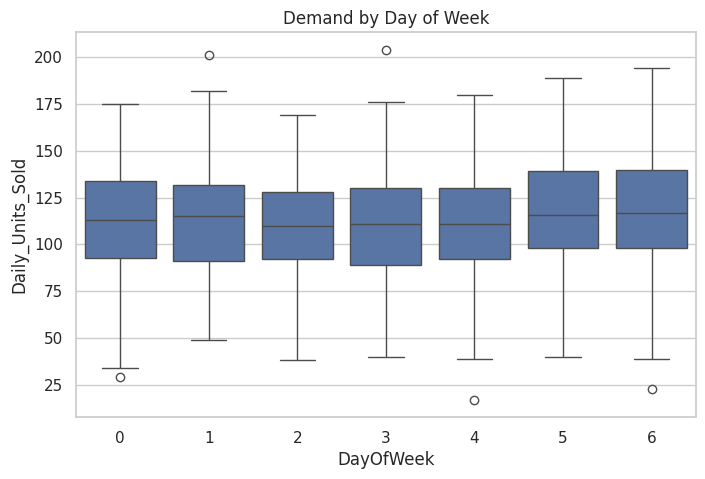

In [16]:
# @title Demand by day of week

# Draw a boxplot to compare demand across days of the week.
plt.figure(figsize=(8,5))
sns.boxplot(x="DayOfWeek", y="Daily_Units_Sold", data=df)
plt.title("Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Daily Units Sold")
plt.show()

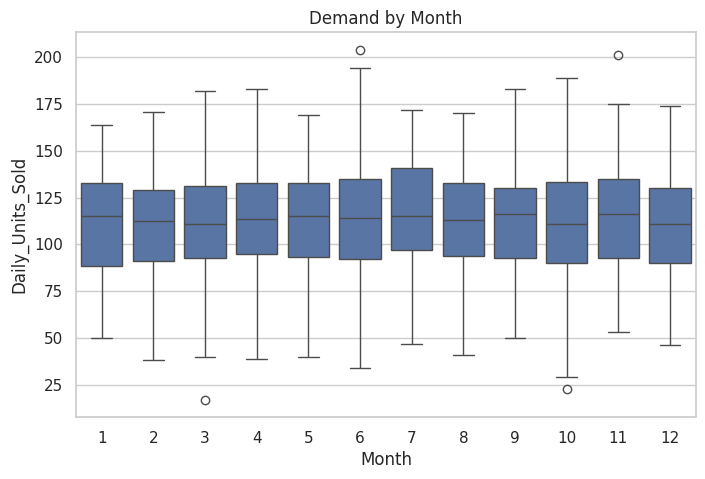

In [17]:
# @title Demand by month

# Draw a boxplot to compare demand across different months.
plt.figure(figsize=(8,5))
sns.boxplot(x="Month", y="Daily_Units_Sold", data=df)
plt.title("Demand by Month")
plt.xlabel("Month")
plt.ylabel("Daily Units Sold")
plt.show()

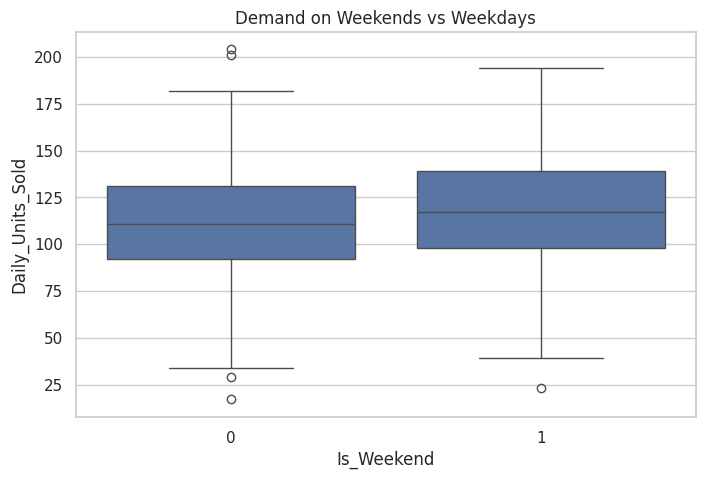

In [18]:
# @title Weekend vs weekday demand

# Compare demand between weekdays (0) and weekends (1).
plt.figure(figsize=(8,5))
sns.boxplot(x="Is_Weekend", y="Daily_Units_Sold", data=df)
plt.title("Demand on Weekends vs Weekdays")
plt.xlabel("Is Weekend")
plt.ylabel("Daily Units Sold")
plt.show()

# Observation: Time-Based Demand Analysis

The time-based analysis suggests that demand changes across different parts of the week and across months.

The main observations are:

- **Average demand is higher on weekends than on weekdays.**
- **Day 5 and Day 6 show the highest average demand**, which is consistent with typical weekend shopping behavior.
- Monthly differences are present, but they are less pronounced than the weekly pattern.

These results indicate that the dataset contains **clear weekly demand variation** and some level of monthly seasonality.

Therefore, time-related features such as **`DayOfWeek`**, **`Month`**, and **`Is_Weekend`** should be retained in the forecasting model.


# Interpretation

The time-based analysis helps determine whether demand varies across different temporal dimensions.

Typical retail observations include:

- Higher demand on weekends due to increased shopping activity
- Seasonal demand changes across months
- Holiday-related demand spikes

If these patterns are present, time variables become important predictors in forecasting models.

# 12. Category-Level Demand Analysis

Products belonging to different categories may have different demand patterns.

For example:

- Electronics may show demand spikes during holiday seasons
- Grocery products may have more stable demand

Analyzing category-level demand helps determine whether the **product category** variable influences demand.

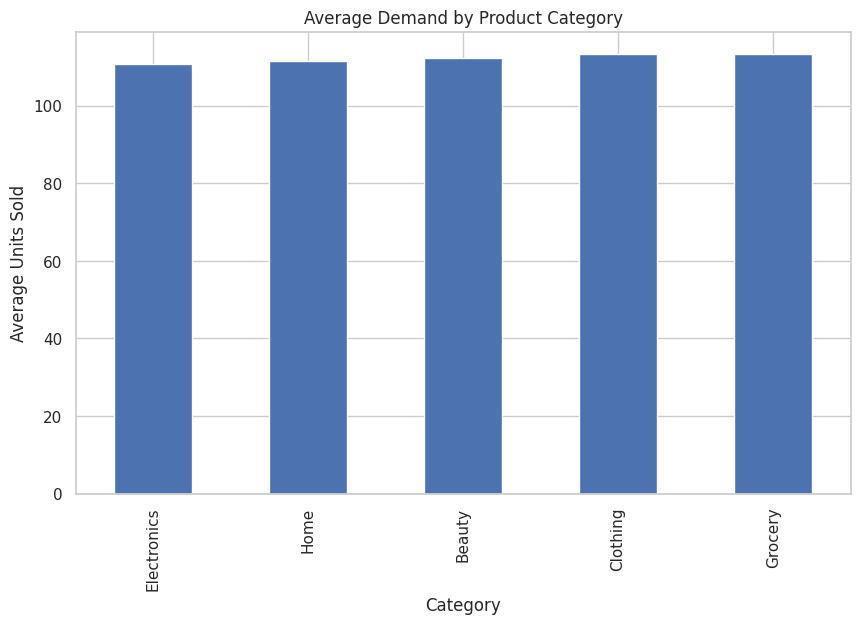

In [19]:
# @title Average demand by category

# Compute the mean sales for each product category.
category_demand = df.groupby("Category")["Daily_Units_Sold"].mean().sort_values()

# Plot the average demand by category.
plt.figure(figsize=(10,6))
category_demand.plot(kind="bar")
plt.title("Average Demand by Product Category")
plt.xlabel("Category")
plt.ylabel("Average Units Sold")
plt.show()

# Observation: Category-Level Demand

The category-wise demand analysis shows that average sales are **fairly close across categories**, so no single category dominates the dataset.

At the same time, there are still visible differences:

- **Grocery** shows the highest average demand.
- **Clothing** and **Beauty** follow closely behind.
- **Electronics** shows the lowest average demand in this dataset.

Although the differences are not extremely large, they are meaningful enough to show that **product category influences sales behavior**.

For this reason, **`Category` should be retained as an explanatory variable** in the demand forecasting model.


# Interpretation

Category-level analysis helps identify whether different product groups behave differently in terms of sales volume.

In this dataset, the variation is moderate rather than extreme, but it is still useful. This means category information provides **business context** and may improve forecasting performance when combined with pricing, traffic, and time-based variables.


# 13. Store-Level Demand Analysis

Retail demand may vary significantly across stores due to:

- geographic location
- customer demographics
- store size and format

Analyzing store-level demand helps determine whether store-specific features are important for forecasting.

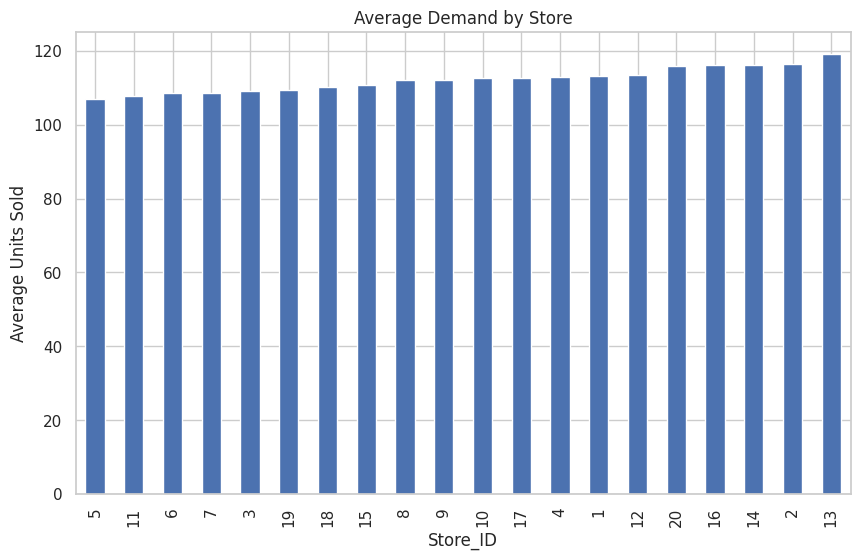

In [20]:
# @title Average demand by store

# Compute the mean sales for each store.
store_demand = df.groupby("Store_ID")["Daily_Units_Sold"].mean().sort_values()

# Plot the average demand by store.
plt.figure(figsize=(10,6))
store_demand.plot(kind="bar")
plt.title("Average Demand by Store")
plt.xlabel("Store ID")
plt.ylabel("Average Units Sold")
plt.show()

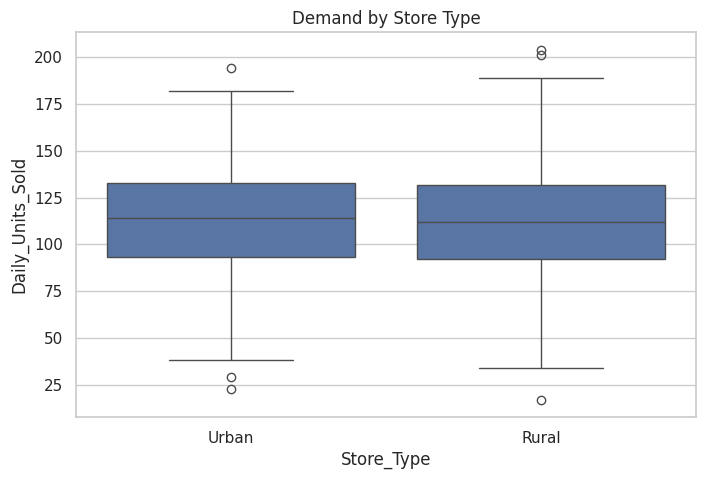

In [21]:
# @title Demand by store type

# Compare demand between different store types.
plt.figure(figsize=(8,5))
sns.boxplot(x="Store_Type", y="Daily_Units_Sold", data=df)
plt.title("Demand by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Daily Units Sold")
plt.show()

# Observation: Store-Level Demand

The store-level analysis shows that demand is **not identical across stores**.

The key observations are:

- There is visible variation in average demand from one store to another.
- When grouped by store type, **Urban stores show slightly higher average demand than Rural stores**.
- The difference between store types is not very large, but it is still meaningful from a business perspective.

This suggests that location-related characteristics may influence demand through factors such as customer density, shopping habits, and store accessibility.

Therefore, both **`Store_ID`** and **`Store_Type`** should be retained in the analysis.


# Interpretation

Store-level variables may not be as influential as price or footfall, but they still capture useful local context.

Including these features allows the model to account for **store-specific demand behavior**, which is important in real retail forecasting systems where the same product may sell differently across locations.


# 14. Summary of Key Insights from Week-2 Analysis

The exploratory data analysis leads to the following important conclusions:

1. The target variable **`Daily_Units_Sold`** is reasonably well distributed and contains only a small number of extreme values. Therefore, it is suitable for further modeling.

2. **Pricing variables**, especially **`Current_Price`**, have the strongest relationship with sales. This is supported by both Random Forest feature importance and permutation importance.

3. **`Footfall_Index`** is the second most important predictor, showing that customer traffic is a major driver of demand.

4. **`Social_Media_Sentiment`** also contributes useful predictive information, suggesting that customer perception may influence purchasing behavior.

5. The VIF analysis shows **high multicollinearity among pricing variables**, particularly `Base_Price`, `Current_Price`, and `Competitor_Price`. These features will still be retained because the project requires that no existing variables be removed.

6. Time-related features, product category, and store-related variables also show meaningful variation and should remain part of the forecasting dataset.

7. PCA indicates that the dataset contains **latent patterns across pricing, temporal, and operational variables**, and these can be represented through additional derived components.

Overall, the dataset contains a strong set of features for building a retail demand forecasting model. However, in a real-world retail setting, forecasting accuracy could be improved further by adding information such as **promotion campaigns, product lifecycle data, customer behavior metrics, and sales channel information**.
